In [42]:
import pandas as pd
import matplotlib.pyplot as plt

perf = pd.read_csv("../processed/scheme_performance_clean.csv")

print(perf.head())

   amfi_code                                   scheme_name       fund_house  \
0     119551     SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund   
1     119552      SBI Bluechip Fund - Direct Plan - Growth  SBI Mutual Fund   
2     119598    SBI Small Cap Fund - Regular Plan - Growth  SBI Mutual Fund   
3     119599     SBI Small Cap Fund - Direct Plan - Growth  SBI Mutual Fund   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth  SBI Mutual Fund   

    category     plan  return_1yr_pct  return_3yr_pct  return_5yr_pct  \
0  Large Cap  Regular           12.42           12.36           14.45   
1  Large Cap   Direct           15.25           11.30           14.23   
2  Small Cap  Regular           24.56           23.39           20.67   
3  Small Cap   Direct           20.59           23.14           21.82   
4       Gilt  Regular            5.34            6.07            5.43   

   benchmark_3yr_pct  alpha  beta  sharpe_ratio  sortino_ratio  \
0              11.49

In [43]:
alpha_beta_df = perf[
    ["amfi_code", "scheme_name", "alpha", "beta"]
]

alpha_beta_df.to_csv(
    "alpha_beta.csv",
    index=False
)

alpha_beta_df.head()

,amfi_code,scheme_name,alpha,beta
0,119551,SBI Bluechip Fund - Regular Plan - Growth,0.87,0.89
1,119552,SBI Bluechip Fund - Direct Plan - Growth,1.78,0.87
2,119598,SBI Small Cap Fund - Regular Plan - Growth,1.23,0.89
3,119599,SBI Small Cap Fund - Direct Plan - Growth,1.13,1.04
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,1.60,0.22


In [44]:
score_df = perf.copy()

score_df["return_rank"] = score_df["return_3yr_pct"].rank()
score_df["sharpe_rank"] = score_df["sharpe_ratio"].rank()
score_df["alpha_rank"] = score_df["alpha"].rank()

score_df["expense_rank"] = score_df["expense_ratio_pct"].rank(
    ascending=False
)

score_df["drawdown_rank"] = score_df["max_drawdown_pct"].rank(
    ascending=False
)

score_df["fund_score"] = (
      score_df["return_rank"] * 0.30
    + score_df["sharpe_rank"] * 0.25
    + score_df["alpha_rank"] * 0.20
    + score_df["expense_rank"] * 0.15
    + score_df["drawdown_rank"] * 0.10
)

score_df["fund_score"] = (
    score_df["fund_score"]
    / score_df["fund_score"].max()
    * 100
)

score_df.to_csv(
    "fund_scorecard.csv",
    index=False
)

score_df.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,...,14288,1.54,4,Moderate,15.0,14.5,9.0,10.5,21.5,46.907216
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,...,1231,0.66,3,Moderate,7.0,5.5,32.0,37.0,29.0,62.972509
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,19259,1.43,5,Very High,40.0,23.0,21.0,20.0,8.0,88.487973
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,36061,0.72,4,Very High,39.0,21.5,18.5,35.5,30.0,100.000000
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,...,24101,0.77,5,Low,3.0,36.0,28.0,32.0,2.0,70.446735


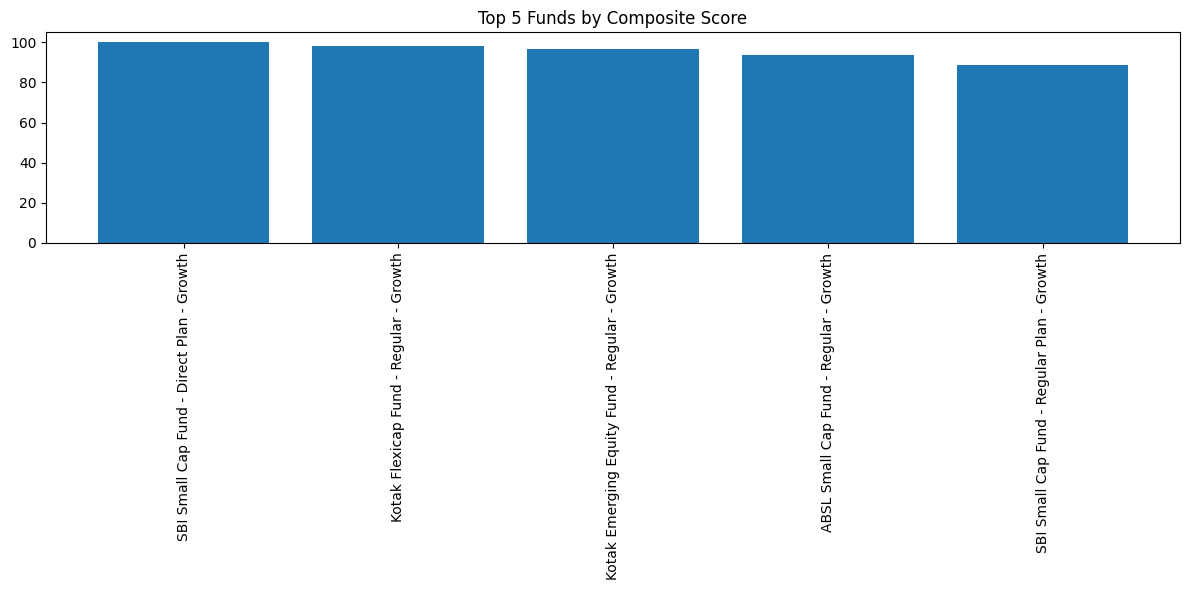

In [45]:
top5 = score_df.nlargest(5, "fund_score")

plt.figure(figsize=(12,6))
plt.bar(top5["scheme_name"], top5["fund_score"])

plt.xticks(rotation=90)
plt.title("Top 5 Funds by Composite Score")

plt.tight_layout()

plt.savefig("benchmark_comparison.png")

plt.show()